In [2]:
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.datasets import mnist
from tensorflow.keras.preprocessing.image import (ImageDataGenerator,load_img,img_to_array)
import matplotlib.pyplot as plt
import os


In [3]:
train_dir = r'C:\Users\maiph\OneDrive\Food recognition\Train'
print("Classes found:\n")

for folder in os.listdir(train_dir):
    print(folder)

Classes found:

Banh khot
Banh mi
Banh xeo
Bun bo Hue
Bun dau mam tom
Bun rieu
Bun thit nuong
Com tam
Goi cuon
Hu tieu
Mi quang
Pho
Xoi xeo


In [4]:
img_width = 200
img_height = 200
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    shear_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

In [6]:
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(200,200),
                                                    batch_size=20,
                                                    class_mode='categorical') #nhieu loai

Found 4530 images belonging to 10 classes.


In [7]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(200,200,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation ="relu"),
    Dropout(0.5), #reduce overfitting
    Dense(10,activation='softmax')
])

c:\Users\maiph\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,802 (33.42 MB)

 Trainable params: 8,761,802 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
epochs = 100

history = model.fit(

    train_generator,

#    validation_data=validation_generator,

    epochs=epochs
)


Epoch 1/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 52s 228ms/step - accuracy: 0.1605 - loss: 2.2408
Epoch 2/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 62s 272ms/step - accuracy: 0.2073 - loss: 2.1386
Epoch 3/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 64s 284ms/step - accuracy: 0.2174 - loss: 2.1072
Epoch 4/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 65s 285ms/step - accuracy: 0.2411 - loss: 2.0765
Epoch 5/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 65s 287ms/step - accuracy: 0.2347 - loss: 2.0466
Epoch 6/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 63s 277ms/step - accuracy: 0.2572 - loss: 2.0206
Epoch 7/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 63s 279ms/step - accuracy: 0.2640 - loss: 1.9877
Epoch 8/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 63s 279ms/step - accuracy: 0.2832 - loss: 1.9560
Epoch 9/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 58s 256ms/step - accuracy: 0.2874 - loss: 1.9307
Epoch 10/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 65s 287ms/step - accuracy: 0.2850 - loss: 1.9175
Epoch 11/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 64s 282ms/step - accuracy: 0.3046 - loss: 1.9032
Epoch 12

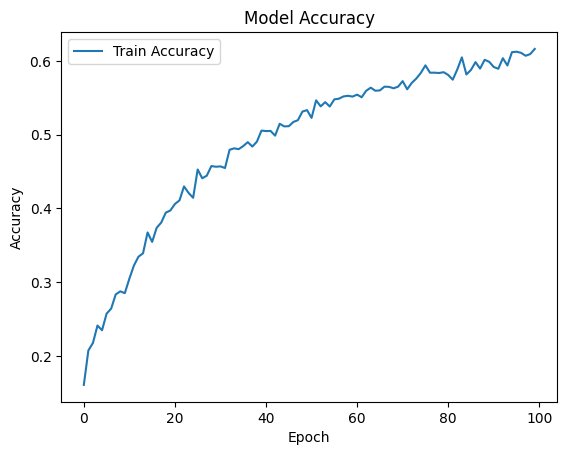

In [10]:
plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)
#plt.plot(
#    history.history['val_accuracy'],
#    label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [15]:
model.save("food_model.h5")
print("Model saved successfully!")

Model saved successfully!


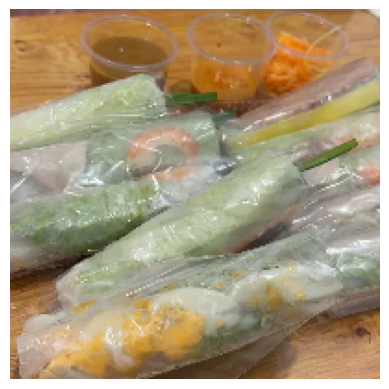

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Predicted Food: Goi cuon


In [16]:
test_image_path = r'C:\Users\maiph\OneDrive\Food recognition\goi cuon.jpg'

img = load_img(
    test_image_path,
    target_size=(img_width, img_height)
)
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = {
    v:k for k,v in train_generator.class_indices.items()}
food_name = class_labels[predicted_class]
print("\nPredicted Food:", food_name)



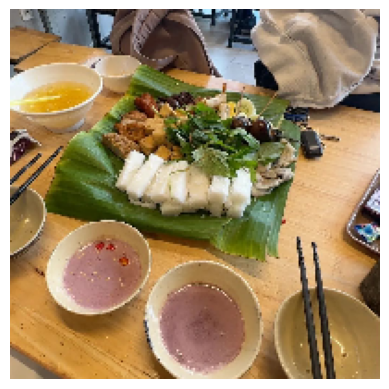

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Predicted Food: Bun dau mam tom


In [17]:
test_image_path = r'C:\Users\maiph\OneDrive\Food recognition\bun dau mam tom.jpg'

img = load_img(
    test_image_path,
    target_size=(img_width, img_height)
)
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = {
    v:k for k,v in train_generator.class_indices.items()}
food_name = class_labels[predicted_class]
print("\nPredicted Food:", food_name)



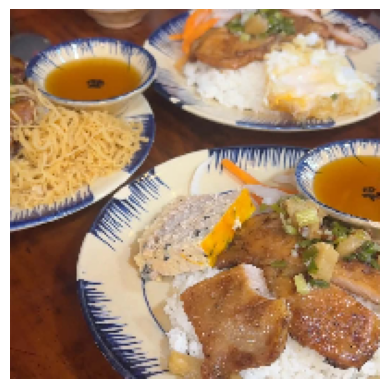

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Predicted Food: Com tam


In [20]:
test_image_path = r'C:\Users\maiph\OneDrive\Food recognition\com tam.jpg'

img = load_img(
    test_image_path,
    target_size=(img_width, img_height)
)
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = {
    v:k for k,v in train_generator.class_indices.items()}
food_name = class_labels[predicted_class]
print("\nPredicted Food:", food_name)



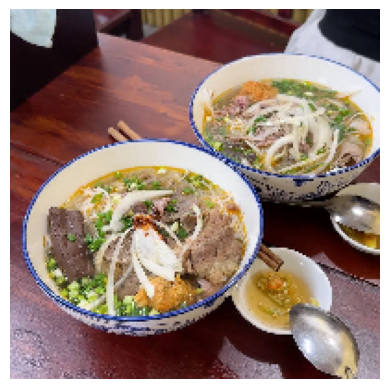

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Predicted Food: Bun bo Hue


In [21]:
test_image_path = r'C:\Users\maiph\OneDrive\Food recognition\bun bo tuyt.jpg'

img = load_img(
    test_image_path,
    target_size=(img_width, img_height)
)
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = {
    v:k for k,v in train_generator.class_indices.items()}
food_name = class_labels[predicted_class]
print("\nPredicted Food:", food_name)



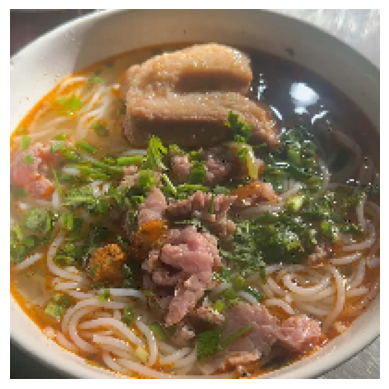

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Predicted Food: Bun bo Hue


In [23]:
test_image_path = r'C:\Users\maiph\OneDrive\Food recognition\bun bo sl.jpg'

img = load_img(
    test_image_path,
    target_size=(img_width, img_height)
)
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = {
    v:k for k,v in train_generator.class_indices.items()}
food_name = class_labels[predicted_class]
print("\nPredicted Food:", food_name)



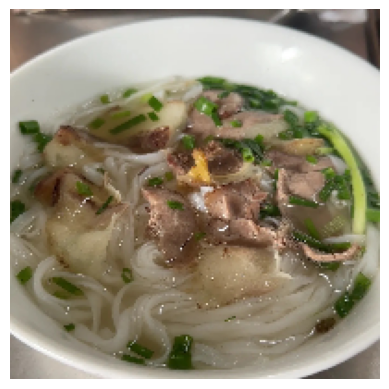

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

Predicted Food: Pho


In [24]:
test_image_path = r'C:\Users\maiph\OneDrive\Food recognition\pho.jpg'

img = load_img(
    test_image_path,
    target_size=(img_width, img_height)
)
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = {
    v:k for k,v in train_generator.class_indices.items()}
food_name = class_labels[predicted_class]
print("\nPredicted Food:", food_name)

